# 04 - Query Results & Visualization 

SQL queries across both 'point_defect_runs' and 'grain_boundary_runs' tables.
Key questions:
1. How does defect density scale with implantation dose?
2. Does anneal temperature reduce defect density?
3. How does disordered fraction scale with misorientation angle?

In [2]:
import sqlite3
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import warnings 
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi":150,
    "axes.spines.top":False,
    "axes.spines.right":False,
    "font.size":11
})

conn = sqlite3.connect("defect_db.sqlite")
print("Connected to defect_db.sqlite")

Connected to defect_db.sqlite


In [5]:
df_mono = pd.read_sql("SELECT * FROM point_defect_runs",conn)
df_gb = pd.read_sql("SELECT * FROM grain_boundary_runs",conn)

print(f"Point defect runs: {len(df_mono)}")
print(f"Grain boundary runs: {len(df_gb)}")
print("\nDefect density range:")
print(f" min: {df_mono['defect_density_cm2'].min():.2e}")
print(f" max: {df_mono['defect_density_cm2'].max():.2e}")
print("\nDisordered fraction by angle:")
print(df_gb[["misorientation_angle","disordered_fraction"]].to_string(index=False))

Point defect runs: 64
Grain boundary runs: 3

Defect density range:
 min: 3.19e+14
 max: 3.39e+15

Disordered fraction by angle:
 misorientation_angle  disordered_fraction
                 15.0              0.09125
                 30.0              0.24500
                 45.0              0.37000


In [6]:
# keep only the latest 16 unique runs
conn.execute("DELETE FROM point_defect_runs WHERE id > 16")
conn.commit()
df_mono = pd.read_sql("SELECT * FROM point_defect_runs",conn)
print(f"Point defect runs after cleanup: {len(df_mono)} rows")

Point defect runs after cleanup: 16 rows


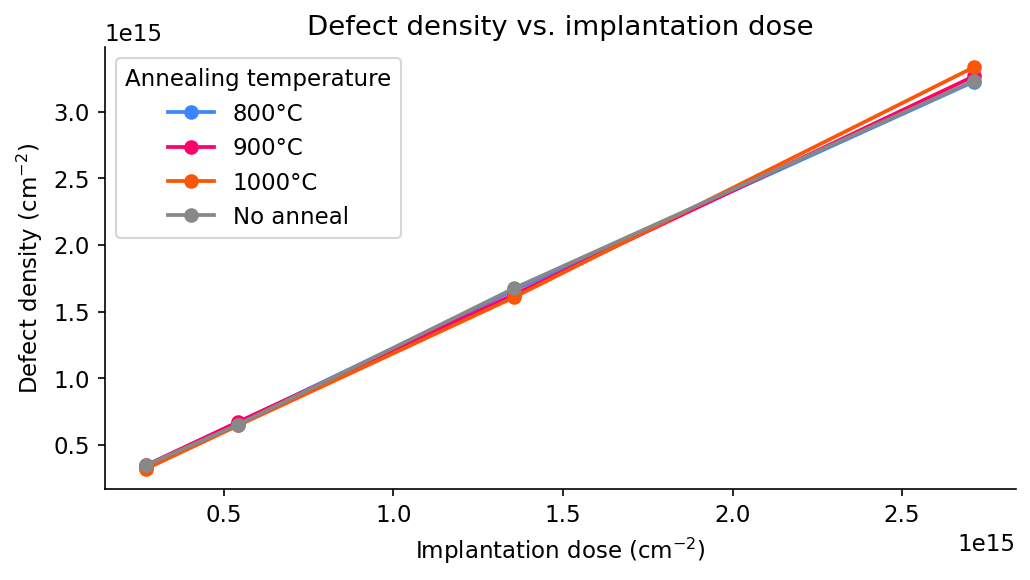

Saved to figures/defect_density_vs_dose.png


In [9]:
fig, ax = plt.subplots(figsize=(7,4))
colors = {None: "#888888", 800.0: "#3a86ff", 900.0: "#ff006e", 1000.0: "#fb5607"}
labels = {None: "No anneal", 800.0: "800°C", 900.0: "900°C", 1000.0: "1000°C"}

for temp, group in df_mono.groupby("anneal_temp_c",dropna=False):
    group = group.sort_values("dose_per_cm2")
    label = labels[temp] if temp in labels else labels[None]
    color = colors[temp] if temp in colors else colors[None]
    ax.plot(group["dose_per_cm2"], group["defect_density_cm2"], marker="o", label=label, color=color, linewidth=1.8)

ax.set_xlabel("Implantation dose (cm$^{-2}$)")
ax.set_ylabel("Defect density (cm$^{-2}$)")
ax.set_title("Defect density vs. implantation dose")
ax.legend(title="Annealing temperature")
ax.ticklabel_format(style="sci", scilimits=(0,0), axis="both")

plt.tight_layout()
plt.savefig("figures/defect_density_vs_dose.png",dpi=150)
plt.show()
print("Saved to figures/defect_density_vs_dose.png")

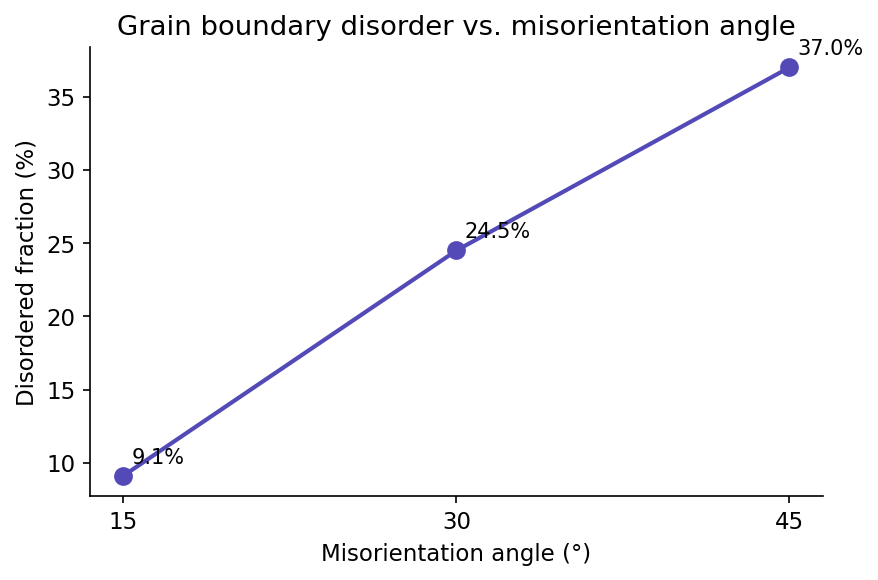

Saved to figures/disordered_fraction_vs_angle.png


In [12]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(df_gb["misorientation_angle"],df_gb["disordered_fraction"]*100,marker="o",color="#534AB7",linewidth=2,markersize=8)

for _, row in df_gb.iterrows():
    ax.annotate(f"{row['disordered_fraction']*100:.1f}%", 
                xy=(row["misorientation_angle"], row["disordered_fraction"]*100),
                xytext=(4,6),textcoords="offset points", fontsize=10)

ax.set_xlabel("Misorientation angle (°)")
ax.set_ylabel("Disordered fraction (%)")
ax.set_title("Grain boundary disorder vs. misorientation angle")
ax.set_xticks([15,30,45])

plt.tight_layout()
plt.savefig("figures/disordered_fraction_vs_angle.png",dpi=150)
plt.show()
print("Saved to figures/disordered_fraction_vs_angle.png")

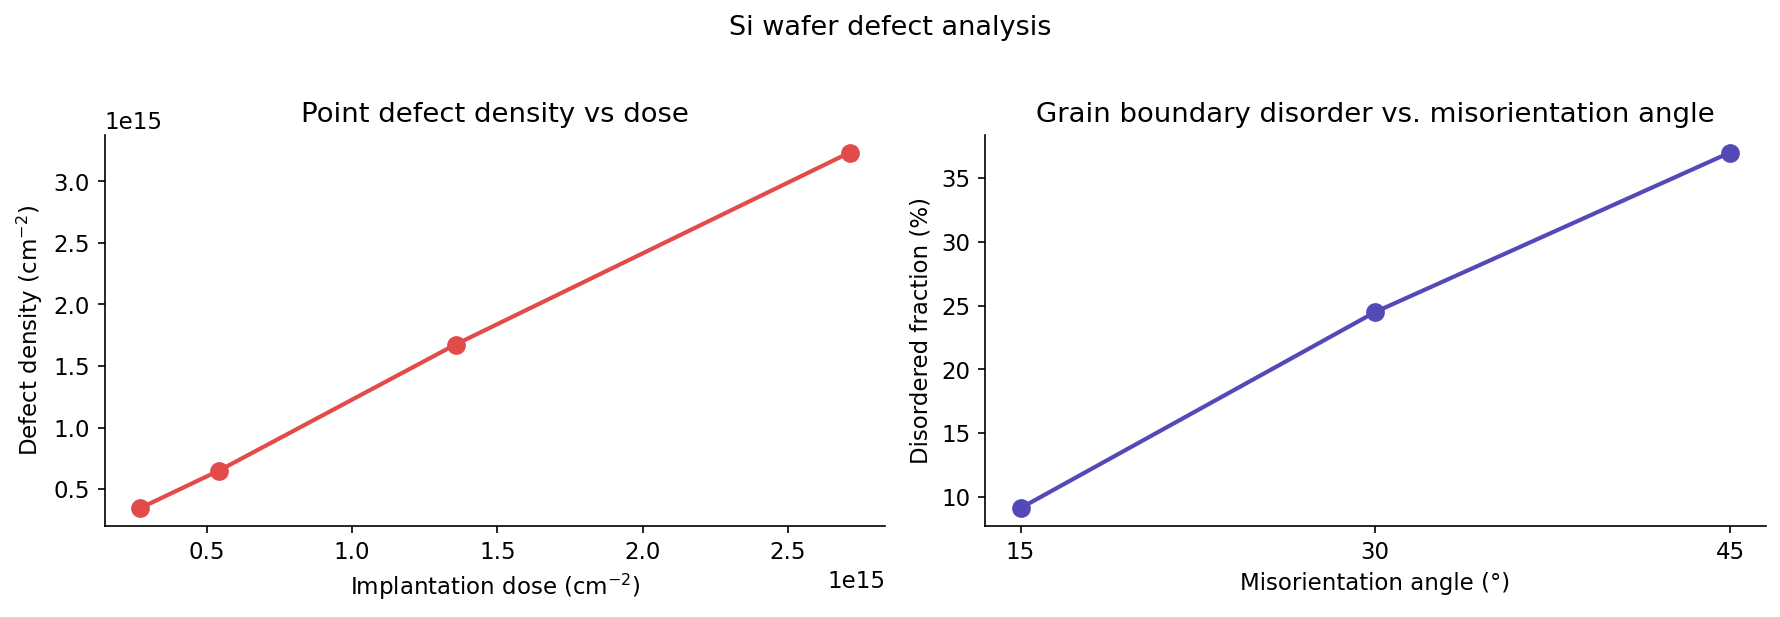

Saved to figures/summary_panel.png


In [14]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))

# left: defect density vs. dose (no anneal only for clarity)
no_anneal = df_mono[df_mono["anneal_temp_c"].isna()].sort_values("dose_per_cm2")
ax1.plot(no_anneal["dose_per_cm2"], no_anneal["defect_density_cm2"], marker="o", color="#E24B4A", linewidth=2, markersize=8)
ax1.set_xlabel("Implantation dose (cm$^{-2}$)")
ax1.set_ylabel("Defect density (cm$^{-2}$)")
ax1.set_title("Point defect density vs dose")
ax1.ticklabel_format(style="sci", scilimits=(0,0), axis="both")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# right: disordered fraction vs. angle
ax2.plot(df_gb["misorientation_angle"], df_gb["disordered_fraction"]*100, marker="o", color="#534AB7", linewidth=2, markersize=8)
ax2.set_xlabel("Misorientation angle (°)")
ax2.set_ylabel("Disordered fraction (%)")
ax2.set_title("Grain boundary disorder vs. misorientation angle")
ax2.set_xticks([15,30,45])
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Si wafer defect analysis",fontsize=13,y=1.02)
plt.tight_layout()
plt.savefig("figures/summary_panel.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved to figures/summary_panel.png")

In [15]:
conn.close()
print("Done.")

Done.
